In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab
from matplotlib import legend_handler

# Fijamos el estilo de la gráfica
plt.style.use('petroff10')

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Comparación bootstraps sin estratificar

In [4]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_s_e=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_f_1.csv", index_col=0)
# Base de bootstrap por votos (directo)
df_boostraps_votos_se=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Directo/Distintas_muestras_bootstrap_votos_dir_sin_est_f_1.csv", index_col=0)

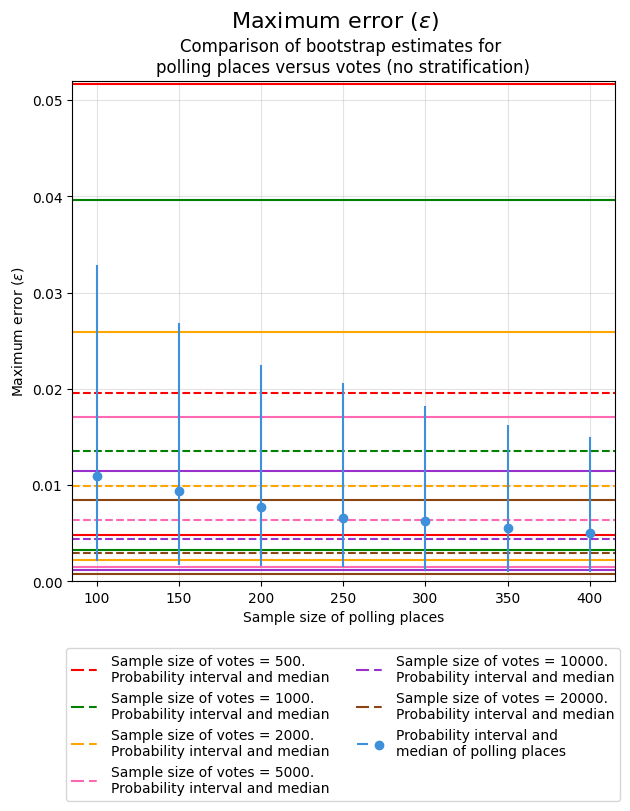

In [ ]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5),dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6.5),dpi=300)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_s_e["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Error_maximo_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Error_maximo_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Error_maximo_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Error_maximo_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Error_maximo_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval and \nmedian of polling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

#plt.suptitle('Maximum error ($\\epsilon$) compared (both bootstraps) \n no estratification', fontsize=16, y=0.96)
#plt.suptitle('Comparison of the maximum error \n($\\epsilon$) of two bootstraps (no stratification)', fontsize=14, y=0.96)
plt.suptitle('Maximum error ($\\epsilon$)', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

plt.xlabel('Sample size of polling places')
plt.ylabel('Maximum error ($\\epsilon$)');
plt.ylim((0,0.052));
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

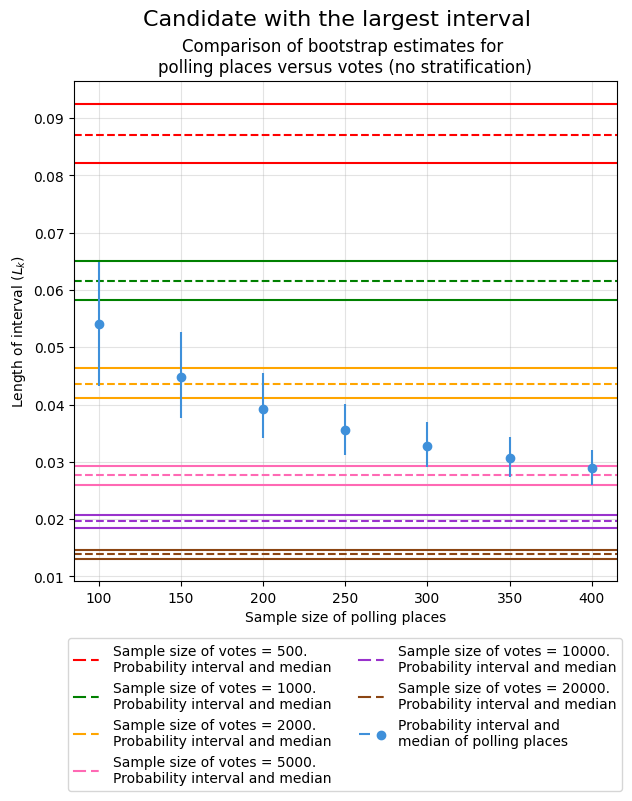

In [7]:

# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6.5),dpi=300)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_s_e["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval and \nmedian of polling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.1), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');
plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

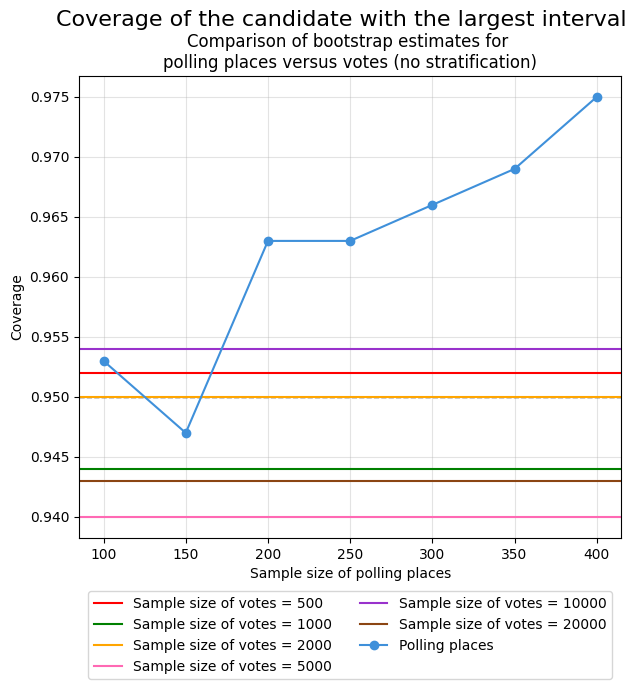

In [8]:
fig = plt.figure(figsize=(7, 6), dpi=100)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_candidato_cob"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Intervalo_M_grande_candidato_cob"], marker='o', label='Polling places')

# sns.pointplot(ax=ax,
#     data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Estratificación"
# ).set_title("Cobertura para intervalos más grandes (ambos bootstrap)");
# ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

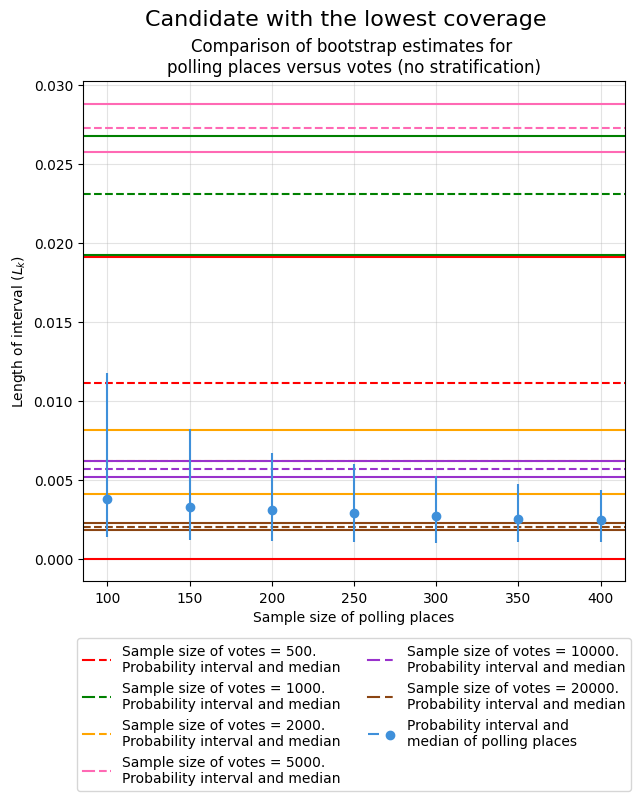

In [9]:

# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5), dpi=100)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_s_e["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cobertura_m_inter_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval and \nmedian of polling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.1), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');
plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

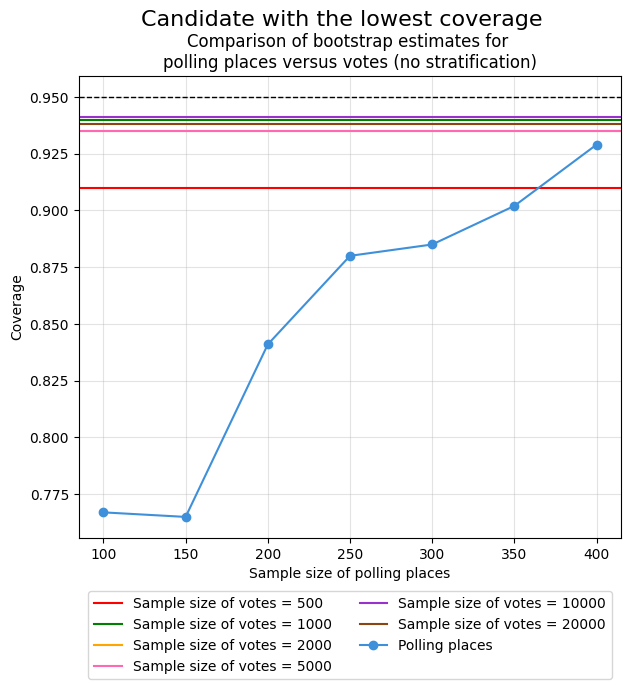

In [ ]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)


# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_candidato"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cobertura_m_candidato"], marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

### Gráficas de las coberturas por candidato

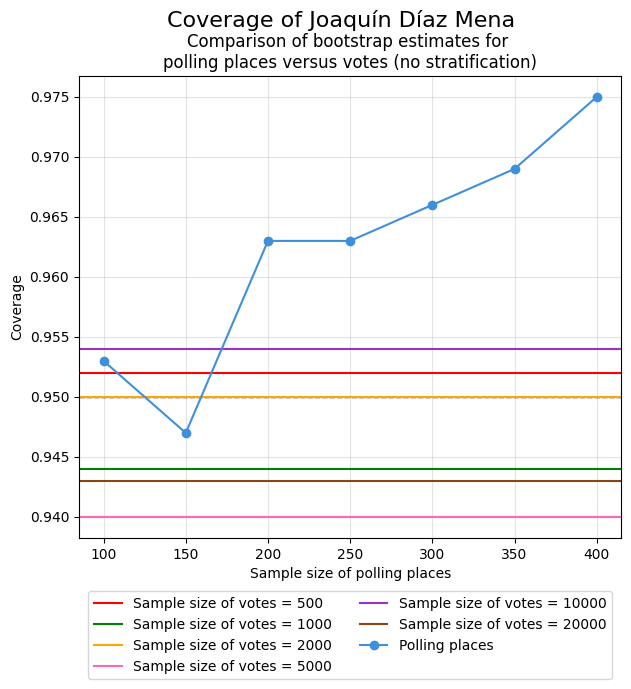

In [ ]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_JOAQUIN_DIAZ_MENA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cob_JOAQUIN_DIAZ_MENA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);


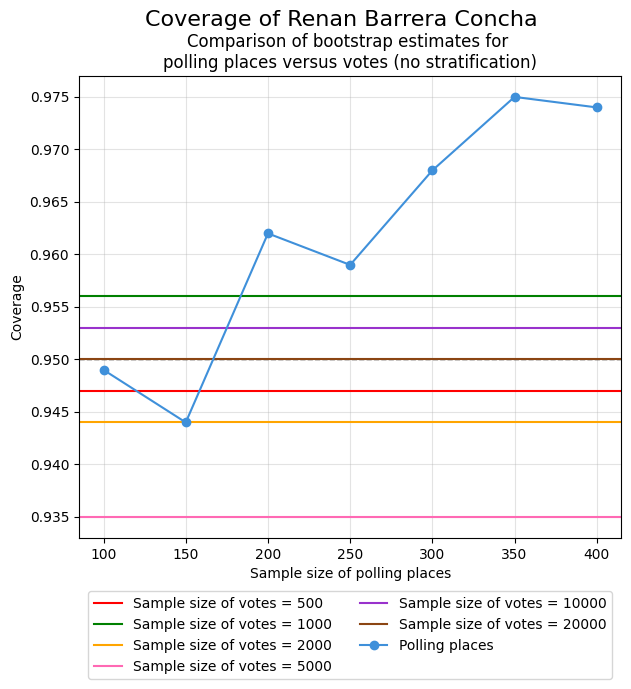

In [24]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_RENAN_BARRERA_CONCHA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cob_RENAN_BARRERA_CONCHA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

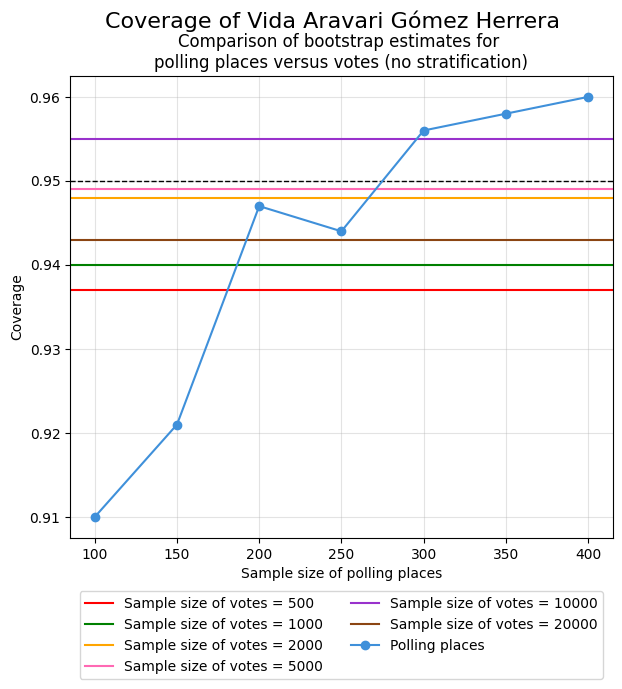

In [26]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)


# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

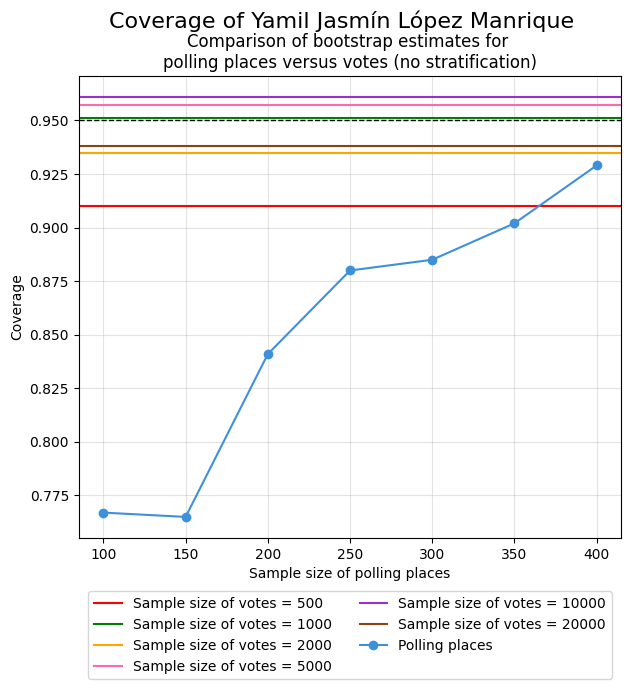

In [28]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

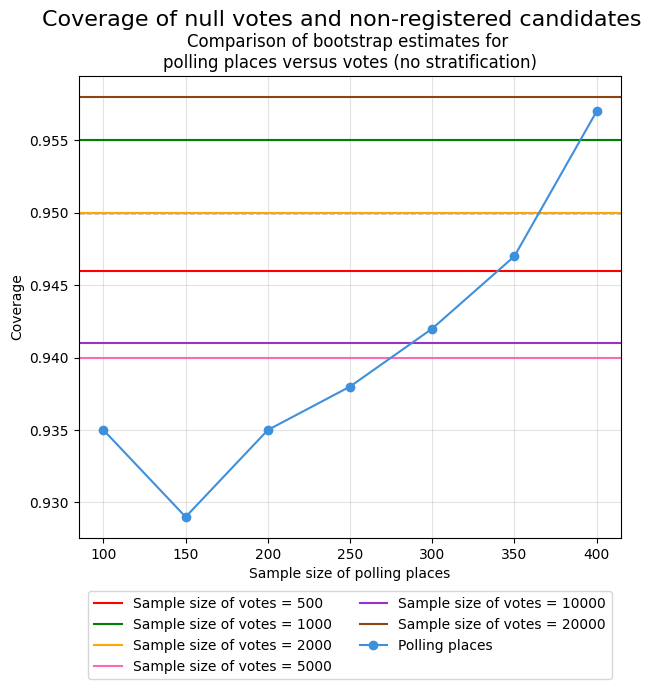

In [30]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_VOTOS_NULOS_CAND_NO_REGIS"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Cob_VOTOS_NULOS_CAND_NO_REGIS"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for \npolling places versus votes (no stratification)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

## Comparación bootstraps estratificados

In [4]:
# Leemos las bases
# Base de bootstrap por casillas sin estratificar
df_boostraps_c_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_f_1.csv", index_col=0)

# Base de bootstrap por votos (directo)
df_boostraps_votos_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Directo/Distintas_muestras_bootstrap_votos_dir_estratificado_f_1.csv", index_col=0)

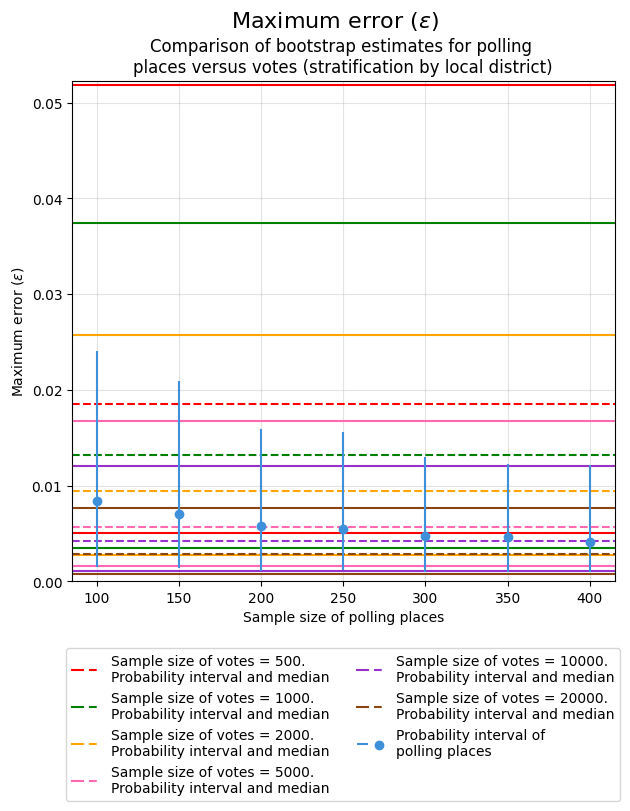

In [12]:


# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5),dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6.5),dpi=300)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_est["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Error_maximo_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Error_maximo_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Error_maximo_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Error_maximo_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Error_maximo_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval of \npolling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

#plt.suptitle('Maximum error ($\\epsilon$) compared (both bootstraps) \n no estratification', fontsize=16, y=0.96)
#plt.suptitle('Comparison of the maximum error \n($\\epsilon$) of two bootstraps (no stratification)', fontsize=14, y=0.96)
plt.suptitle('Maximum error ($\\epsilon$)', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

plt.xlabel('Sample size of polling places')
plt.ylabel('Maximum error ($\\epsilon$)');
plt.ylim((0,0.0523));
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

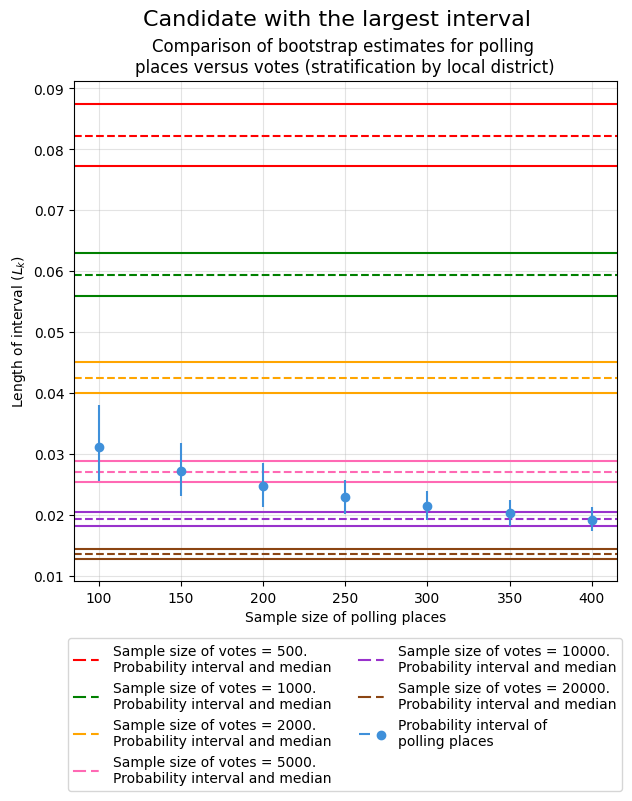

In [14]:

# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6.5),dpi=300)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_est["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Intervalo_M_grande_inter_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval of \npolling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.1), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');
plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

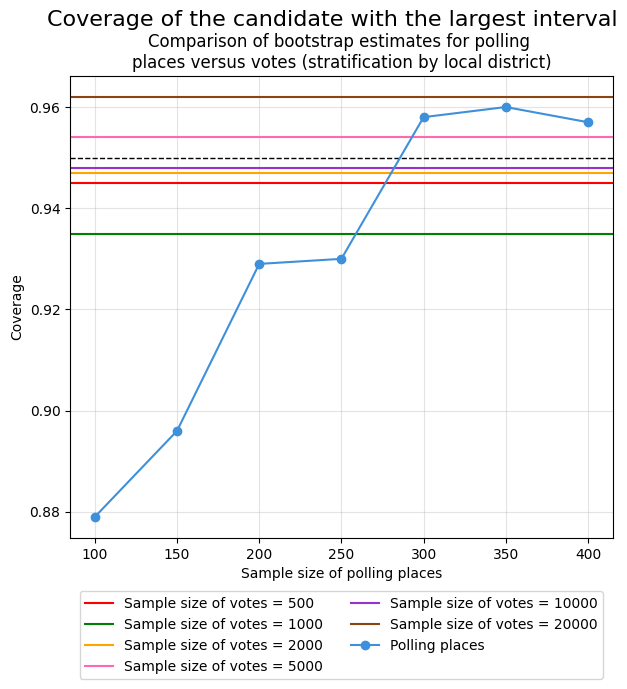

In [43]:
fig = plt.figure(figsize=(7, 6), dpi=100)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_candidato_cob"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Intervalo_M_grande_candidato_cob"], marker='o', label='Polling places')


plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

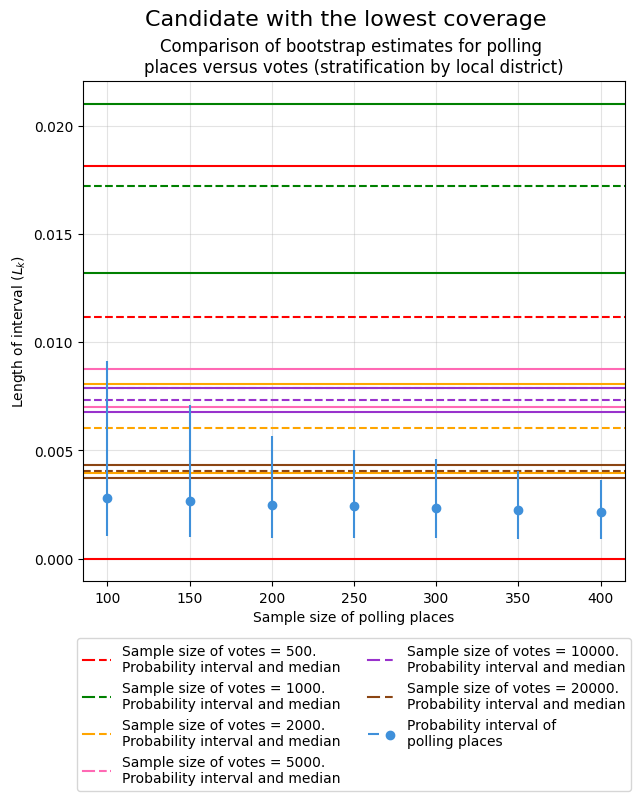

In [44]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6.5), dpi=100)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Sample size of votes = {i[1]}. \nProbability interval and median");
    line_1=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_est["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_025"].values, df_boostraps_c_est[df_boostraps_c_est["Tamaño_muestra_casillas"]==val]["Cobertura_m_inter_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cobertura_m_inter_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Probability interval of \npolling places")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.1), ncol=2, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');
plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

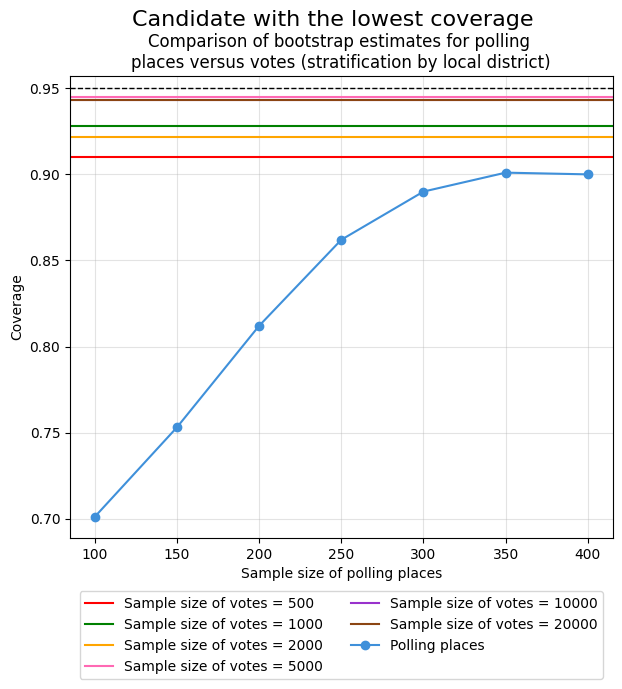

In [20]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_candidato"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cobertura_m_candidato"], marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

### Gráficas de las coberturas por candidato

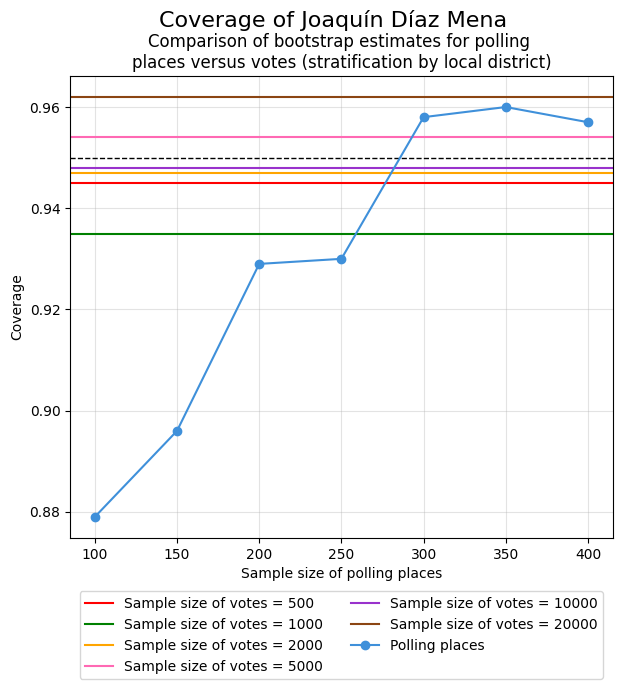

In [11]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_JOAQUIN_DIAZ_MENA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cob_JOAQUIN_DIAZ_MENA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

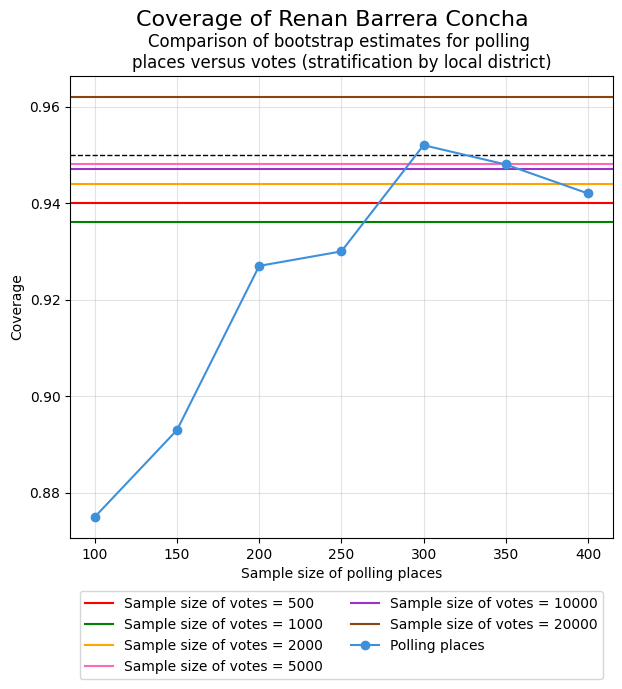

In [13]:
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_RENAN_BARRERA_CONCHA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cob_RENAN_BARRERA_CONCHA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);


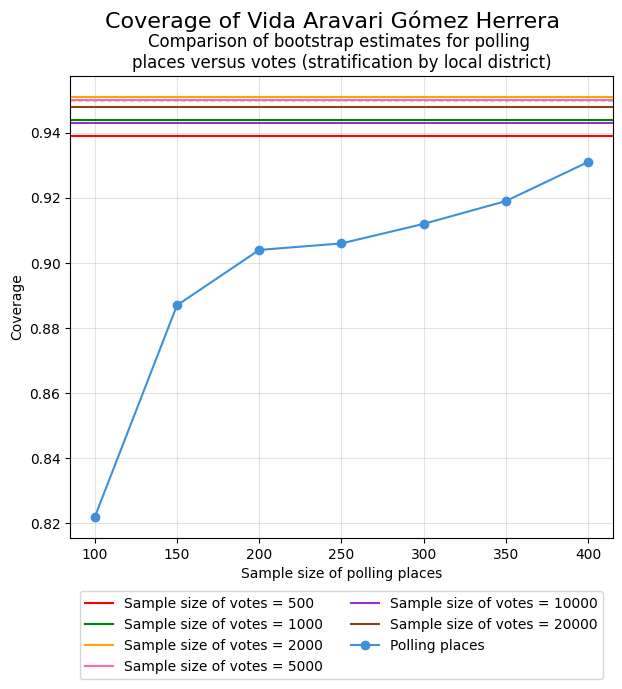

In [15]:
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");
    
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);


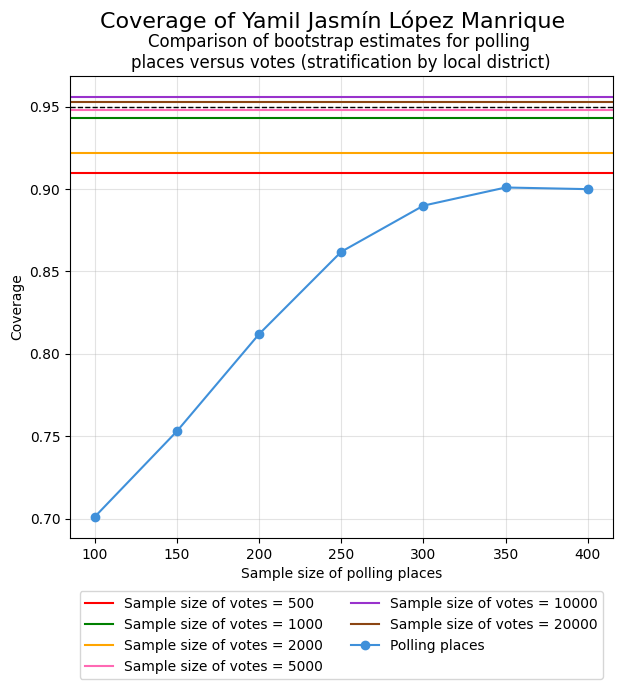

In [17]:
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);


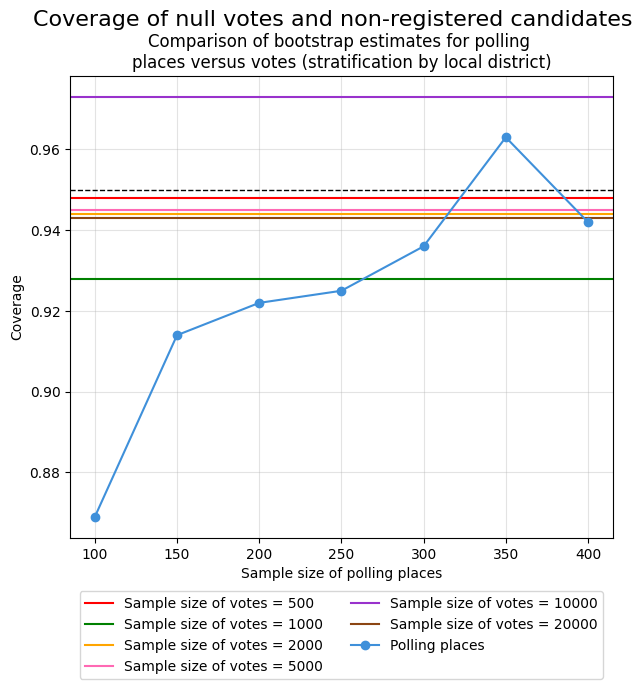

In [19]:
fig = plt.figure(figsize=(7, 6), dpi=100)

#fig = plt.figure(figsize=(7, 6),dpi=300)

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_VOTOS_NULOS_CAND_NO_REGIS"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Sample size of votes = {i[1]}");

plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"],df_boostraps_c_est["Cob_VOTOS_NULOS_CAND_NO_REGIS"], marker='o', label='Polling places')

plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.99)
plt.title('Comparison of bootstrap estimates for polling \nplaces versus votes (stratification by local district)');

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
